Loading datasets...
INFO: Target codes: [11, 22, 33, 44, 55]
INFO: Standard codes: [12, 13, 14, 15, 21, 23, 24, 25, 31, 32, 34, 35, 41, 42, 43, 45, 51, 52, 53, 54]
INFO: Target codes (epochs): [5, 10]
INFO: Standard codes (epochs): [1, 2, 3, 4, 6, 7, 8, 9]


/tmp/ipython-input-2757918043.py:501: UserWarning: The figure layout has changed to tight
  plt.tight_layout(h_pad=1.35)



✓ Combined QC figure saved to: /content/drive/MyDrive/DataLiteracyProject/Preprocessed_VisualOddball/QC_plots_sub-001


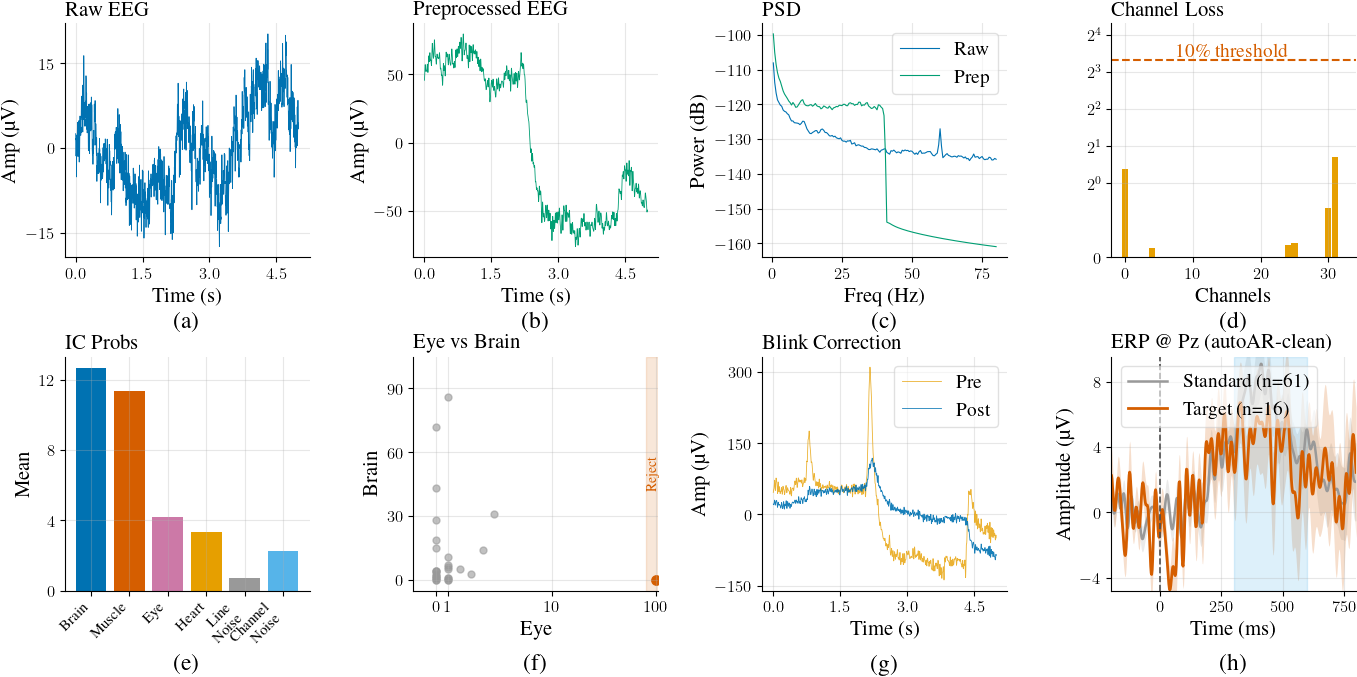

In [38]:
import os, re, glob, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.io import loadmat
import mne
from tueplots import bundles

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# CONFIGURATION
DATA_ROOT = "/content/drive/MyDrive/DataLiteracyProject"
PROJECT = os.path.join(DATA_ROOT, "Preprocessed_VisualOddball")
SUB = "sub-001"
TASK = "visualoddball"
QC_DIR = os.path.join(PROJECT, "QC_plots_sub-001")
os.makedirs(QC_DIR, exist_ok=True)

BIDS_EVENTS_DIR = os.path.join(DATA_ROOT, "OriginalData")

# Color palette
COLORS = {
    "blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
    "vermillion": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9",
    "gray": "#999999", "darkgray": "#4D4D4D", "lightgray": "#CCCCCC"
}

def pick_existing(expected_path, fallback_glob):
    if os.path.exists(expected_path): return expected_path
    hits = sorted(glob.glob(fallback_glob))
    if not hits: raise FileNotFoundError(f"Missing: {expected_path}")
    return hits[0]

def pick_channel(ch_names, preferred):
    lower = [c.lower() for c in ch_names]
    for p in preferred:
        if p.lower() in lower: return ch_names[lower.index(p.lower())]
    return ch_names[0]

def format_ax(ax, sparse_x=False, sparse_y=False):
    ax.grid(True, alpha=0.3, linestyle='-')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if sparse_y: ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    if sparse_x: ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

def load_rejglobal_sidecar(autoar_set_path):
    """Load rejection global sidecar file"""
    base, fname = os.path.split(autoar_set_path)
    root, _ = os.path.splitext(fname)
    rej_path = os.path.join(base, root + "_rejglobal.mat")
    if not os.path.exists(rej_path):
        return None
    mat = loadmat(rej_path)
    if "rejglobal" not in mat:
        return None
    return np.asarray(mat["rejglobal"]).astype(bool).ravel()

def read_epochs_eeglab_safe(set_path, preload=True):
    """Version-safe EEGLAB epochs reader"""
    import inspect
    reader = getattr(mne, "read_epochs_eeglab", None)
    if reader is None:
        reader = getattr(mne.io, "read_epochs_eeglab", None)
    if reader is None:
        raise ImportError("Could not find an EEGLAB epochs reader in this MNE version.")

    sig = inspect.signature(reader)
    kwargs = {"verbose": "ERROR"}

    if "preload" in sig.parameters:
        kwargs["preload"] = preload
        epochs = reader(set_path, **kwargs)
    else:
        epochs = reader(set_path, **kwargs)
        if preload and hasattr(epochs, "load_data"):
            epochs.load_data()
    return epochs

def robust_ylim_from_data(y, pad_frac=0.08):
    """Calculate robust y-limits from data"""
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return None
    lo, hi = np.percentile(y, [1, 99])
    if lo == hi:
        lo -= 1.0
        hi += 1.0
    pad = (hi - lo) * pad_frac
    return (lo - pad, hi + pad)

def find_events_json_for_subject(sub_id, task="visualoddball"):
    """Find the events JSON file for a subject (optional)"""
    candidates = [
        os.path.join(BIDS_EVENTS_DIR, f"{sub_id}_task-{task}_events.json"),
        os.path.join(BIDS_EVENTS_DIR, sub_id, "eeg", f"{sub_id}_task-{task}_events.json"),
        os.path.join(BIDS_EVENTS_DIR, sub_id, f"{sub_id}_task-{task}_events.json"),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    pattern = os.path.join(BIDS_EVENTS_DIR, "**", f"{sub_id}_task-{task}_events.json")
    hits = glob.glob(pattern, recursive=True)
    if hits:
        return sorted(hits)[0]
    return None

def get_target_and_standard_codes(events_json_path):
    """Extract target and standard codes from events JSON"""
    if events_json_path is None:
        return [], []

    with open(events_json_path, "r") as f:
        meta = json.load(f)

    levels = meta.get("value", {}).get("Levels", {})
    target_codes, standard_codes = [], []

    for code_key, desc in levels.items():
        mcode = re.search(r"-?\d+", str(code_key))
        if not mcode:
            continue
        code = int(mcode.group(0))
        if code >= 200:
            continue

        m1 = re.search(r"target\s*\(for that block\)\s*([A-Za-z])", str(desc), flags=re.I)
        m2 = re.search(r"stimulus type\s*([A-Za-z])", str(desc), flags=re.I)
        if not (m1 and m2):
            continue

        block_letter = m1.group(1).upper()
        stim_letter = m2.group(1).upper()
        if block_letter == stim_letter:
            target_codes.append(code)
        else:
            standard_codes.append(code)

    return sorted(set(target_codes)), sorted(set(standard_codes))

def classify_events_from_epochs(epochs):
    """
    Classify events as target/standard directly from epochs event_id.
    Uses multiple strategies to identify target vs standard trials.
    Returns: (target_codes, standard_codes, epoch_event_codes)
    """
    event_id = epochs.event_id
    epoch_event_codes = epochs.events[:, 2]

    target_codes = []
    standard_codes = []

    # Strategy 1: Look for explicit target/standard labels
    for label, code in event_id.items():
        label_lower = str(label).lower()
        if any(kw in label_lower for kw in ['target', 'rare', 'deviant', 'oddball']):
            target_codes.append(code)
        elif any(kw in label_lower for kw in ['standard', 'frequent', 'nontarget', 'non-target', 'nontgt']):
            standard_codes.append(code)

    # Strategy 2: numeric two-digit scheme where tens==ones => target
    if not target_codes and not standard_codes:
        numeric_codes = {}
        for label, code in event_id.items():
            try:
                num = int(str(label).strip())
                if 10 <= num < 100:
                    numeric_codes[num] = code
            except ValueError:
                continue

        if numeric_codes:
            for num, code in numeric_codes.items():
                tens = num // 10
                ones = num % 10
                if tens == ones:
                    target_codes.append(code)
                else:
                    standard_codes.append(code)

    # Strategy 3: frequency (targets rare)
    if not target_codes and not standard_codes:
        code_counts = {}
        for code in epoch_event_codes:
            code_counts[code] = code_counts.get(code, 0) + 1

        total = len(epoch_event_codes)
        for code, count in code_counts.items():
            freq = count / total
            if freq < 0.3:
                target_codes.append(code)
            else:
                standard_codes.append(code)

    return target_codes, standard_codes, epoch_event_codes

def add_panel_labels_below_aligned_by_row(fig, axes_grid, labels_grid, fontsize, pad_points_top=2.0, pad_points_bottom=6.0):
    """
    Put panel labels centered *below* each subplot without clashing with xlabels/ticklabels.
    Labels are aligned to a common baseline per row (top row baseline + bottom row baseline).
    """
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    inv = fig.transFigure.inverted()
    fig_h_in = fig.get_size_inches()[1]

    def points_to_figy(points):
        return (points / 72.0) / fig_h_in

    for r, (row_axes, row_labels) in enumerate(zip(axes_grid, labels_grid)):
        pad_points = pad_points_top if r == 0 else pad_points_bottom
        pad_fig = points_to_figy(pad_points)

        y0s = []
        xcenters = []
        for ax in row_axes:
            bb = ax.get_tightbbox(renderer=renderer).transformed(inv)
            y0s.append(bb.y0)
            pos = ax.get_position()
            xcenters.append(pos.x0 + pos.width / 2.0)

        y_baseline = min(y0s) - pad_fig
        y_baseline = max(y_baseline, 0.001)

        for x, lab in zip(xcenters, row_labels):
            fig.text(x, y_baseline, lab, ha='center', va='top',
                     fontweight='bold', fontsize=fontsize)

# LOAD DATA
print("Loading datasets...")
RAW_SET = pick_existing(os.path.join(PROJECT, "01_raw", f"{SUB}_task-{TASK}_eeg_raw.set"),
                        os.path.join(PROJECT, "01_raw", f"{SUB}*raw.set"))
PREPROC_SET = pick_existing(os.path.join(PROJECT, "02_preprocessed", f"{SUB}_task-{TASK}_eeg_preprocessed.set"),
                            os.path.join(PROJECT, "02_preprocessed", f"{SUB}*preprocessed.set"))
POSTICA_SET = pick_existing(os.path.join(PROJECT, "06_postICA", f"{SUB}_task-{TASK}_eegpostICA.set"),
                            os.path.join(PROJECT, "06_postICA", f"{SUB}*postICA.set"))
AUTOAR_SET = pick_existing(os.path.join(PROJECT, "08_AR", f"{SUB}_task-{TASK}_autoAR.set"),
                           os.path.join(PROJECT, "08_AR", f"{SUB}*autoAR.set"))
PREICA_LOSS_XLSX = os.path.join(PROJECT, "03_preICA", "COCOA_preICAextremeloss.xlsx")
ICLABEL_XLSX = pick_existing(os.path.join(PROJECT, "05_ICLabel", f"{SUB}_task-{TASK}_eeg_ICclassifications.xlsx"),
                             os.path.join(PROJECT, "05_ICLabel", f"{SUB}*ICclassifications.xlsx"))

raw = mne.io.read_raw_eeglab(RAW_SET, preload=True, verbose="ERROR")
pre = mne.io.read_raw_eeglab(PREPROC_SET, preload=True, verbose="ERROR")
post = mne.io.read_raw_eeglab(POSTICA_SET, preload=True, verbose="ERROR")

pz_raw = pick_channel(raw.ch_names, ["Pz", "CPz", "POz"])
pz_pre = pick_channel(pre.ch_names, ["Pz", "CPz", "POz"])
fr_pre = pick_channel(pre.ch_names, ["Fp1", "FP1", "Fz", "AFz"])
fr_post = pick_channel(post.ch_names, ["Fp1", "FP1", "Fz", "AFz"])

# CREATE COMBINED 2x4 FIGURE
plt.rcParams.update(bundles.icml2024(column="full", nrows=2, ncols=4))

plt.rcParams.update({
    "figure.figsize": (14, 7),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
    "legend.framealpha": 0.6
})

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
ax_a, ax_b, ax_c, ax_d = axes[0]
ax_e, ax_f, ax_g, ax_h = axes[1]

# --- (a) Raw EEG ---
d = raw.get_data(picks=[pz_raw], stop=int(5*raw.info["sfreq"]))[0] * 1e6
d = d - np.mean(d)
t = np.arange(len(d)) / raw.info["sfreq"]
ax_a.plot(t, d, color=COLORS["blue"], linewidth=0.6)
ax_a.set_title("Raw EEG", loc='left', fontweight='bold')
ax_a.set_xlabel("Time (s)", fontweight='bold')
ax_a.set_ylabel("Amp (µV)", fontweight='bold')
format_ax(ax_a, sparse_x=True, sparse_y=True)

# --- (b) Preprocessed EEG ---
d = pre.get_data(picks=[pz_pre], stop=int(5*pre.info["sfreq"]))[0] * 1e6
d = d - np.mean(d)
t = np.arange(len(d)) / pre.info["sfreq"]
ax_b.plot(t, d, color=COLORS["green"], linewidth=0.6)
ax_b.set_title("Preprocessed EEG", loc='left', fontweight='bold')
ax_b.set_xlabel("Time (s)", fontweight='bold')
ax_b.set_ylabel("Amp (µV)", fontweight='bold')
format_ax(ax_b, sparse_x=True, sparse_y=True)

# --- (c) PSD ---
def get_psd(inst, pick):
    spec = inst.compute_psd(method="welch", picks=[pick], fmin=0.5, fmax=80,
                            n_fft=int(2*inst.info['sfreq']), verbose=False)
    return spec.freqs, 10 * np.log10(spec.get_data()[0])

fr, psd_r = get_psd(raw, pz_raw)
fp, psd_p = get_psd(pre, pz_pre)
ax_c.plot(fr, psd_r, color=COLORS["blue"], label="Raw", linewidth=0.8)
ax_c.plot(fp, psd_p, color=COLORS["green"], label="Prep", linewidth=0.8)
ax_c.set_title("PSD", loc='left', fontweight='bold')
ax_c.set_xlabel("Freq (Hz)", fontweight='bold')
ax_c.set_ylabel("Power (dB)", fontweight='bold')
ax_c.legend(loc='upper right', frameon=True)
format_ax(ax_c, sparse_x=True)

# --- (d) Channel Loss ---
loss = pd.read_excel(PREICA_LOSS_XLSX)
row = loss[loss.astype(str).apply(lambda x: x.str.contains(SUB, case=False)).any(axis=1)]
if row.empty: row = loss.head(1)
vals = pd.to_numeric(row.iloc[0, 1:], errors='coerce').dropna().values
if len(vals) > 0:
    ax_d.bar(np.arange(len(vals)), vals, color=COLORS["orange"], width=0.9)
    ax_d.set_yscale('symlog', base=2, linthresh=1.0)
    ax_d.axhline(10, color=COLORS["vermillion"], ls="--", lw=1.5)
    ax_d.set_yticks([0, 1, 2, 4, 8, 16])
    ax_d.set_ylim(0, 20)

    ax_d.text(
        0.50, 10, r"10\% threshold",
        transform=ax_d.get_yaxis_transform(),  # x in axes coords, y in data coords
        ha="center", va="bottom",
        color=COLORS["vermillion"],
        fontsize=plt.rcParams["legend.fontsize"],
        fontweight="bold",
        clip_on=False
    )

ax_d.set_title("Channel Loss", loc='left', fontweight='bold')
ax_d.set_xlabel("Channels", fontweight='bold')
ax_d.set_ylabel("% Bad", fontweight='bold')
format_ax(ax_d)

# --- (e) IC Classification ---
T = pd.read_excel(ICLABEL_XLSX)
classes = ["Brain", "Muscle", "Eye", "Heart", "Line_Noise", "Channel_Noise"]
classes = [c for c in classes if c in T.columns]
if T[classes].max().max() <= 1.01: T[classes] *= 100
probs = T[classes].mean()
colors_bar = [COLORS["blue"], COLORS["vermillion"], COLORS["purple"],
              COLORS["orange"], COLORS["gray"], COLORS["sky"]][:len(probs)]
ax_e.bar(range(len(probs)), probs.values, color=colors_bar)
ax_e.set_xticks(range(len(probs)))
ax_e.set_xticklabels([s.replace('_', '\n') for s in probs.index],
                     rotation=45, ha='right', fontsize=10.8, fontweight='bold')  # -10% from 12
ax_e.set_title("IC Probs", loc='left', fontweight='bold')
ax_e.set_ylabel("Mean %", fontweight='bold')
format_ax(ax_e, sparse_y=True)

# --- (f) Eye vs Brain Scatter ---
eye = T["Eye"].values * (100 if T["Eye"].max() <= 1.01 else 1)
brain = T["Brain"].values * (100 if T["Brain"].max() <= 1.01 else 1)
ax_f.axvspan(80, 105, color=COLORS["vermillion"], alpha=0.15, label="Reject zone")
is_eye = eye > 80
ax_f.scatter(eye[~is_eye], brain[~is_eye], s=25, c=COLORS["gray"], alpha=0.6)
ax_f.scatter(eye[is_eye], brain[is_eye], s=45.5, c=COLORS["vermillion"])
ax_f.set_xscale('symlog', linthresh=10)
ax_f.set_xlim(-2, 105); ax_f.set_ylim(-5, 105)
ax_f.set_xticks([0, 1, 10, 100])
ax_f.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax_f.tick_params(axis='x', labelrotation=0)
ax_f.set_title("Eye vs Brain", loc='left', fontweight='bold')
ax_f.set_xlabel("Eye %", fontweight='bold')
ax_f.set_ylabel("Brain %", fontweight='bold')
ax_f.text(92, 50, "Reject", rotation=90, color=COLORS["vermillion"],
          ha='center', va='center', fontsize=10, fontweight='bold')
format_ax(ax_f, sparse_y=True)

# --- (g) Blink Correction ---
d_pre = pre.get_data(picks=[fr_pre], stop=int(5*pre.info["sfreq"]))[0] * 1e6
d_post = post.get_data(picks=[fr_post], stop=int(5*post.info["sfreq"]))[0] * 1e6
t = np.arange(len(d_pre)) / pre.info["sfreq"]
ax_g.plot(t, d_pre, color=COLORS["orange"], label="Pre", linewidth=0.6, alpha=0.8)
ax_g.plot(t, d_post, color=COLORS["blue"], label="Post", linewidth=0.6, alpha=0.9)
ax_g.set_title("Blink Correction", loc='left', fontweight='bold')
ax_g.set_xlabel("Time (s)", fontweight='bold')
ax_g.set_ylabel("Amp (µV)", fontweight='bold')
ax_g.legend(loc='upper right', frameon=True)
format_ax(ax_g, sparse_x=True, sparse_y=True)

# --- (h) ERP Target vs Standard ---
try:
    epochs = read_epochs_eeglab_safe(AUTOAR_SET, preload=True)

    pz_ep = pick_channel(epochs.ch_names, ["Pz", "CPz", "POz"])
    pz_idx = epochs.ch_names.index(pz_ep)

    rejglobal = load_rejglobal_sidecar(AUTOAR_SET)
    if rejglobal is not None and len(rejglobal) == len(epochs):
        good = ~rejglobal
    else:
        good = np.ones(len(epochs), dtype=bool)

    events_json = find_events_json_for_subject(SUB, task=TASK)
    target_codes, standard_codes = get_target_and_standard_codes(events_json)

    if not target_codes and not standard_codes:
        print("INFO: No events JSON found, classifying events from epochs...")
        target_codes, standard_codes, _ = classify_events_from_epochs(epochs)

    print(f"INFO: Target codes: {target_codes}")
    print(f"INFO: Standard codes: {standard_codes}")

    epoch_event_codes = epochs.events[:, 2]

    is_t = good & np.isin(epoch_event_codes, target_codes) if target_codes else np.zeros(len(epochs), dtype=bool)
    is_s = good & np.isin(epoch_event_codes, standard_codes) if standard_codes else np.zeros(len(epochs), dtype=bool)

    if is_t.sum() == 0 and is_s.sum() == 0 and (target_codes or standard_codes):
        print("WARNING: JSON codes didn't match epochs codes; re-classifying from epochs.event_id...")
        target_codes2, standard_codes2, _ = classify_events_from_epochs(epochs)
        print(f"INFO: Target codes (epochs): {target_codes2}")
        print(f"INFO: Standard codes (epochs): {standard_codes2}")

        is_t = good & np.isin(epoch_event_codes, target_codes2) if target_codes2 else np.zeros(len(epochs), dtype=bool)
        is_s = good & np.isin(epoch_event_codes, standard_codes2) if standard_codes2 else np.zeros(len(epochs), dtype=bool)

    if is_t.sum() == 0 and is_s.sum() == 0:
        print("WARNING: Could not separate target/standard, using all epochs")
        is_s = good.copy()

    data = epochs.get_data()
    times_ms = epochs.times * 1000.0

    def mean_sem(arr_2d):
        if arr_2d.size == 0:
            return None, None
        mean = np.nanmean(arr_2d, axis=0)
        sem = np.nanstd(arr_2d, axis=0, ddof=0) / np.sqrt(max(arr_2d.shape[0], 1))
        return mean, sem

    s_trials = data[is_s, pz_idx, :] * 1e6 if is_s.sum() > 0 else np.empty((0, data.shape[-1]))
    t_trials = data[is_t, pz_idx, :] * 1e6 if is_t.sum() > 0 else np.empty((0, data.shape[-1]))

    erp_s, sem_s = mean_sem(s_trials)
    erp_t, sem_t = mean_sem(t_trials)

    if erp_s is None and erp_t is None:
        raise RuntimeError("No epochs available after filtering.")

    if erp_s is not None:
        label_s = f"Standard (n={is_s.sum()})" if is_t.sum() > 0 else f"All trials (n={is_s.sum()})"
        ax_h.plot(times_ms, erp_s, color=COLORS["gray"], linewidth=1.8, label=label_s)
        ax_h.fill_between(times_ms, erp_s - sem_s, erp_s + sem_s,
                          color=COLORS["gray"], alpha=0.2, linewidth=0)

    if erp_t is not None:
        ax_h.plot(times_ms, erp_t, color=COLORS["vermillion"], linewidth=2.0,
                  label=f"Target (n={is_t.sum()})")
        ax_h.fill_between(times_ms, erp_t - sem_t, erp_t + sem_t,
                          color=COLORS["vermillion"], alpha=0.2, linewidth=0)

    ax_h.axvline(0, color=COLORS["darkgray"], linestyle="--", linewidth=1.2)
    ax_h.axvspan(300, 600, color=COLORS["sky"], alpha=0.2)

    ax_h.set_xlim(-200, 800)
    ax_h.set_title(f"ERP @ {pz_ep} (autoAR-clean)", loc='left', fontweight='bold')
    ax_h.set_xlabel("Time (ms)", fontweight='bold')
    ax_h.set_ylabel("Amplitude (µV)", fontweight='bold')

    y_all = []
    if erp_s is not None: y_all.append(erp_s)
    if erp_t is not None: y_all.append(erp_t)
    if y_all:
        yl = robust_ylim_from_data(np.concatenate(y_all))
        if yl: ax_h.set_ylim(*yl)

    ax_h.legend(loc='upper left', frameon=True)

except Exception as e:
    import traceback
    print(f"Failed to generate ERP plot (h): {e}")
    traceback.print_exc()
    ax_h.text(0.5, 0.5, f"ERP Error:\n{str(e)[:50]}", ha='center', va='center',
              transform=ax_h.transAxes, fontsize=10, wrap=True)
    ax_h.set_title("ERP @ Pz", loc='left', fontweight='bold')

format_ax(ax_h, sparse_x=True, sparse_y=True)

# SAVE FIGURE
plt.tight_layout(h_pad=1.35)

panel_font = int(np.ceil(0.90 * plt.rcParams["axes.labelsize"] * 1.20))
add_panel_labels_below_aligned_by_row(
    fig,
    axes_grid=[axes[0, :], axes[1, :]],
    labels_grid=[["(a)", "(b)", "(c)", "(d)"], ["(e)", "(f)", "(g)", "(h)"]],
    fontsize=panel_font,
    pad_points_top=5.0,      # moved slightly down
    pad_points_bottom=-1.0    # moved slightly down
)

fig.savefig(os.path.join(QC_DIR, "qc_combined_figure.pdf"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(QC_DIR, "qc_combined_figure.png"), dpi=300, bbox_inches='tight')
print(f"\n✓ Combined QC figure saved to: {QC_DIR}")
plt.show()
